# 03 估计

问题与建模思路参考 Allen B. Downey *Think Bayes*（中译《贝叶斯思维》）第 3 章。

**学习目标**：
- 把「未知参数」当作假设空间上的分布来更新
- 比较均匀先验与幂律先验对火车头问题的影响
- 用 CDF / 可信区间概括后验，并看到坦克问题与火车头同构


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

HERE = Path.cwd()
for candidate in [HERE, HERE / "notebooks" / "bayes", HERE.parent]:
    if (candidate / "thinkbayes_mini.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break

from thinkbayes_mini import Suite

%matplotlib inline


## 1. 骰子问题

假设箱子里有 4、6、8、12、20 面骰各一颗。随机摸一颗，掷出 6。各面数骰子的后验？

似然：若假设为 $n$ 面，则

$$
P(\text{点数}=k \mid n) =
\begin{cases}
1/n & 1 \le k \le n \\
0 & \text{否则}
\end{cases}
$$


In [2]:
class Dice(Suite):
    def Likelihood(self, data, hypo):
        if data > hypo:
            return 0
        return 1 / hypo


dice = Dice([4, 6, 8, 12, 20])
dice.Normalize()
dice.Update(6)
print("掷出 6 后:", {h: round(p, 4) for h, p in dice.Items()})
dice.UpdateSet([6, 8, 7, 7, 5, 4])
print("再掷一串后:", {h: round(p, 4) for h, p in dice.Items()})


掷出 6 后: {4: 0.0, 6: 0.3922, 8: 0.2941, 12: 0.1961, 20: 0.1176}
再掷一串后: {4: 0.0, 6: 0.0, 8: 0.9432, 12: 0.0552, 20: 0.0015}


## 2. 火车头问题（均匀先验）

铁路公司有 $N$ 辆火车，编号 $1\ldots N$。你看到编号 $k$，估计 $N$。

似然（均匀抽一辆）：$P(k\mid N)=1/N$（若 $k\le N$，否则 0）。

先取先验：$N \sim \mathrm{Uniform}\{1,\ldots,N_{\max}\}$。


In [3]:
class Train(Suite):
    def Likelihood(self, data, hypo):
        if hypo < data:
            return 0
        return 1 / hypo


def make_uniform_train(n_max: int) -> Train:
    suite = Train(range(1, n_max + 1))
    suite.Normalize()
    return suite


def posterior_mean(suite: Suite) -> float:
    return suite.Mean()


for n_max in [500, 1000, 2000]:
    s = make_uniform_train(n_max)
    s.Update(60)
    print(f"N_max={n_max:4d}  →  后验均值 ≈ {posterior_mean(s):.1f}")


N_max= 500  →  后验均值 ≈ 207.1
N_max=1000  →  后验均值 ≈ 333.4
N_max=2000  →  后验均值 ≈ 552.2


均匀先验下，后验均值对 $N_{\max}$ **敏感**——上界越大，均值被右尾拉得越高。


## 3. 幂律先验

许多公司规模近似幂律：先验

$$
P(N) \propto N^{-\alpha}\quad(\alpha \approx 1)
$$

大 $N$ 事先更不可能，后验对上界更稳健。


幂律 N_max=500 → 均值 ≈ 143.8
幂律 N_max=1000 → 均值 ≈ 178.5
幂律 N_max=2000 → 均值 ≈ 215.6


/var/folders/h3/7zc3322s3y1bwclms8c2rjwc0000gn/T/ipykernel_27975/3129767064.py:22: UserWarning: Glyph 30475 (\N{CJK UNIFIED IDEOGRAPH-770B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h3/7zc3322s3y1bwclms8c2rjwc0000gn/T/ipykernel_27975/3129767064.py:22: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h3/7zc3322s3y1bwclms8c2rjwc0000gn/T/ipykernel_27975/3129767064.py:22: UserWarning: Glyph 32534 (\N{CJK UNIFIED IDEOGRAPH-7F16}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h3/7zc3322s3y1bwclms8c2rjwc0000gn/T/ipykernel_27975/3129767064.py:22: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h3/7zc3322s3y1bwclms8c2rjwc0000gn/T/ipykernel_27975/3129767064.py:22: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h3/7zc3

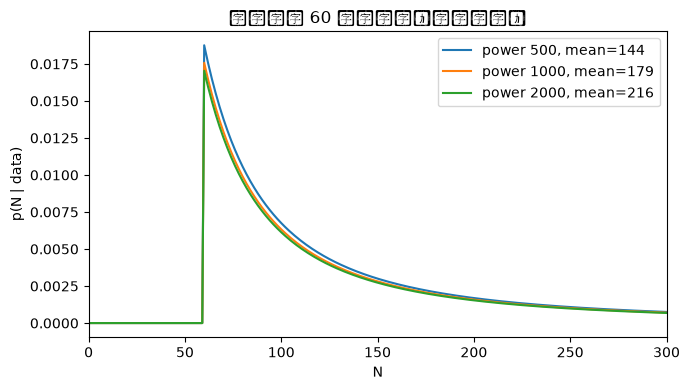

In [4]:
def make_power_train(n_max: int, alpha: float = 1.0) -> Train:
    suite = Train()
    for n in range(1, n_max + 1):
        suite.Set(n, n ** (-alpha))
    suite.Normalize()
    return suite


fig, ax = plt.subplots(figsize=(7, 4))
for n_max, label in [(500, "power 500"), (1000, "power 1000"), (2000, "power 2000")]:
    s = make_power_train(n_max)
    s.Update(60)
    xs, ps = zip(*sorted(s.Items()))
    ax.plot(xs, ps, label=f"{label}, mean={s.Mean():.0f}")
    print(f"幂律 N_max={n_max} → 均值 ≈ {s.Mean():.1f}")

ax.set_xlim(0, 300)
ax.set_xlabel("N")
ax.set_ylabel("p(N | data)")
ax.set_title("看到编号 60 后的后验（幂律先验）")
ax.legend()
plt.tight_layout()


## 4. 可信区间与 CDF

累积分布 $F(x)=P(N\le x)$。对称 $90\%$ 可信区间取百分位 $5\%$ 与 $95\%$：

$$
[F^{-1}(0.05),\, F^{-1}(0.95)]
$$


In [5]:
suite = make_power_train(2000)
suite.UpdateSet([60, 30, 90])  # 多次观测编号
cdf = suite.MakeCdf()
lo, hi = suite.CredibleInterval(90)
print(f"后验均值 = {suite.Mean():.1f}")
print(f"MAP = {suite.MaximumLikelihood()}")
print(f"90% 可信区间 = [{lo}, {hi}]")
print(f"F(100) = P(N≤100) ≈ {cdf.Prob(100):.3f}")


后验均值 = 134.0
MAP = 90
90% 可信区间 = [91, 243]
F(100) = P(N≤100) ≈ 0.294


## 5. 德军坦克问题

缴获坦克序列号，估计总产量——与火车头问题**同构**：观察到的最大编号扮演 $k$，总产量扮演 $N$。
似然同为 $1/N$（在 $N\ge k$ 时）。


In [6]:
# 假设缴获序列号 60（与火车头同一似然）
tank = make_power_train(1000)
tank.Update(60)
print("坦克产量后验均值 ≈", round(tank.Mean(), 1))
print("90% CI:", tank.CredibleInterval(90))


坦克产量后验均值 ≈ 178.5
90% CI: (62, 559)


## 小结

1. 估计 = 在参数网格上放先验，用似然更新，读后验均值 / MAP / 区间。
2. 先验上界与形状会影响结论；幂律往往比「硬切均匀」更稳。
3. 下一章用连续参数（硬币偏向）与 Beta 共轭把网格估计对照解析解。
